# Zajęcie 3 (2024)

In [4]:
np.random.seed(42)
data = np.random.rand(200, 5)
data

array([[0.37454012, 0.95071431, 0.73199394, 0.59865848, 0.15601864],
       [0.15599452, 0.05808361, 0.86617615, 0.60111501, 0.70807258],
       [0.02058449, 0.96990985, 0.83244264, 0.21233911, 0.18182497],
       [0.18340451, 0.30424224, 0.52475643, 0.43194502, 0.29122914],
       [0.61185289, 0.13949386, 0.29214465, 0.36636184, 0.45606998],
       [0.78517596, 0.19967378, 0.51423444, 0.59241457, 0.04645041],
       [0.60754485, 0.17052412, 0.06505159, 0.94888554, 0.96563203],
       [0.80839735, 0.30461377, 0.09767211, 0.68423303, 0.44015249],
       [0.12203823, 0.49517691, 0.03438852, 0.9093204 , 0.25877998],
       [0.66252228, 0.31171108, 0.52006802, 0.54671028, 0.18485446],
       [0.96958463, 0.77513282, 0.93949894, 0.89482735, 0.59789998],
       [0.92187424, 0.0884925 , 0.19598286, 0.04522729, 0.32533033],
       [0.38867729, 0.27134903, 0.82873751, 0.35675333, 0.28093451],
       [0.54269608, 0.14092422, 0.80219698, 0.07455064, 0.98688694],
       [0.77224477, 0.19871568, 0.

In [11]:
print(data.mean())
print(data.std())
x = data[2][0]
# x = data[0][1]

scaler=(x-data.mean())/data.std()
scaler

0.4902565533201336
0.291991256731072


-1.608514118821392

# PCA i wizualizacja skupień

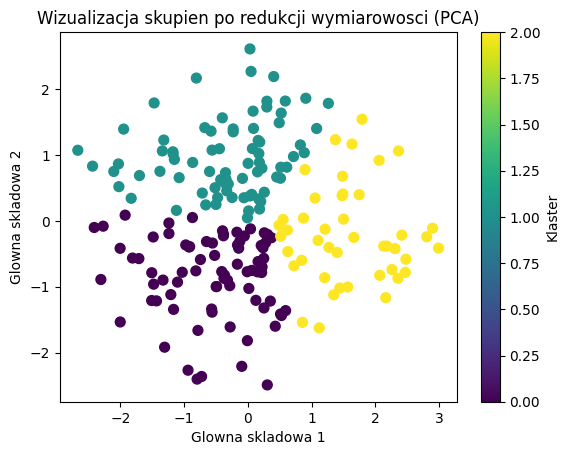

In [1]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Generowanie przykladowych danych
np.random.seed(42)
data = np.random.rand(200, 5)  # 200 punktow w 5 wymiarach

# Standaryzacja danych pewnie robienei danych okolo -1.7 do 0 i 0 do 1.7
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)

# Redukcja wymiarowosci za pomoca PCA do 2d
pca = PCA(n_components=2)
data_pca = pca.fit_transform(data_scaled)

# Klasteryzacja k-means (na potrzeby wizualizacji)
kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(data_pca)

# Wizualizacja wynikow
plt.scatter(data_pca[:, 0], data_pca[:, 1], c=labels, cmap='viridis', s=50)
plt.xlabel('Glowna skladowa 1')
plt.ylabel('Glowna skladowa 2')
plt.title('Wizualizacja skupien po redukcji wymiarowosci (PCA)')
plt.colorbar(label='Klaster')
plt.show()

# Klasteryzacja k-means

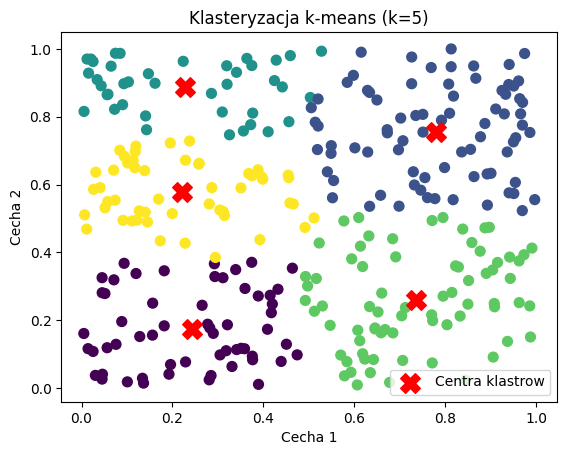

In [18]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Generowanie przykladowych danych
np.random.seed(42)
data = np.random.rand(300, 2)  # 300 punktow w 2 wymiarach

# Klasteryzacja k-means
k = 5  # liczba klastrow
kmeans = KMeans(n_clusters=k, random_state=42)
labels = kmeans.fit_predict(data)

# Wizualizacja wynikow
plt.scatter(data[:, 0], data[:, 1], c=labels, cmap='viridis', s=50)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], 
            c='red', marker='X', s=200, label='Centra klastrow')
plt.title(f'Klasteryzacja k-means (k={k})')
plt.xlabel('Cecha 1')
plt.ylabel('Cecha 2')
plt.legend()
plt.show()

# Klasteryzacja hierarchiczna

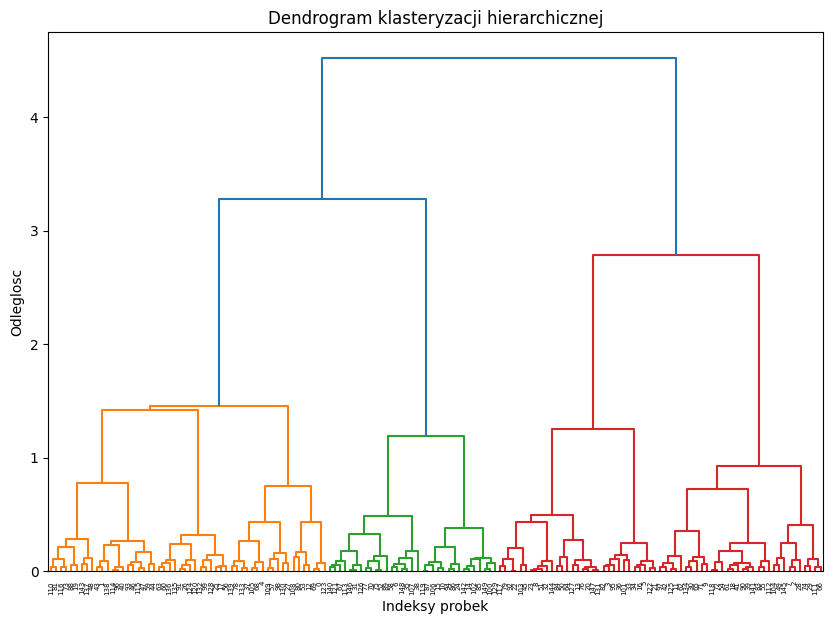

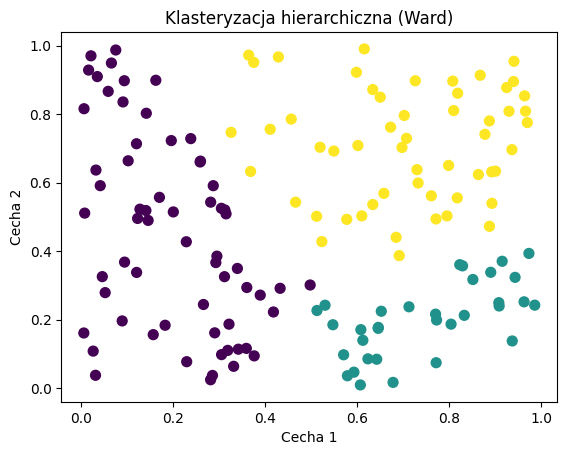

In [2]:
import numpy as np
import scipy.cluster.hierarchy as sch
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
import matplotlib.pyplot as plt

# Generowanie przykladowych danych
np.random.seed(42)
data = np.random.rand(150, 2)  # 150 punktow w 2 wymiarach

# Klasteryzacja hierarchiczna
linked = linkage(data, method='ward')  # Uzycie metody Ward

# Wizualizacja dendrogramu
plt.figure(figsize=(10, 7))
dendrogram(linked, orientation='top', distance_sort='descending', show_leaf_counts=True)
plt.title('Dendrogram klasteryzacji hierarchicznej')
plt.xlabel('Indeksy probek')
plt.ylabel('Odleglosc')
plt.show()

# Wyodrebnienie klastrow na wybranym poziomie
clusters = fcluster(linked, t=3, criterion='maxclust')

# Wizualizacja skupien
plt.scatter(data[:, 0], data[:, 1], c=clusters, cmap='viridis', s=50)
plt.title('Klasteryzacja hierarchiczna (Ward)')
plt.xlabel('Cecha 1')
plt.ylabel('Cecha 2')
plt.show()

# moje dane

In [2]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

path=r"C:\Users\USER098\Documents\GitHub\Artifical_Inteligence_lesson\Data\pd_speech_features.csv"
df = pd.read_csv(path,encoding="utf-8")

df.head()

,id,gender,PPE,DFA,RPDE,numPulses,numPeriodsPulses,meanPeriodPulses,stdDevPeriodPulses,locPctJitter,...,tqwt_kurtosisValue_dec_28,tqwt_kurtosisValue_dec_29,tqwt_kurtosisValue_dec_30,tqwt_kurtosisValue_dec_31,tqwt_kurtosisValue_dec_32,tqwt_kurtosisValue_dec_33,tqwt_kurtosisValue_dec_34,tqwt_kurtosisValue_dec_35,tqwt_kurtosisValue_dec_36,class
0,0,1,0.85247,0.71826,0.57227,240,239,0.008064,0.000087,0.00218,...,1.5620,2.6445,3.8686,4.2105,5.1221,4.4625,2.6202,3.0004,18.9405,1
1,0,1,0.76686,0.69481,0.53966,234,233,0.008258,0.000073,0.00195,...,1.5589,3.6107,23.5155,14.1962,11.0261,9.5082,6.5245,6.3431,45.1780,1
2,0,1,0.85083,0.67604,0.58982,232,231,0.008340,0.000060,0.00176,...,1.5643,2.3308,9.4959,10.7458,11.0177,4.8066,2.9199,3.1495,4.7666,1
3,1,0,0.41121,0.79672,0.59257,178,177,0.010858,0.000183,0.00419,...,3.7805,3.5664,5.2558,14.0403,4.2235,4.6857,4.8460,6.2650,4.0603,1
4,1,0,0.32790,0.79782,0.53028,236,235,0.008162,0.002669,0.00535,...,6.1727,5.8416,6.0805,5.7621,7.7817,11.6891,8.2103,5.0559,6.1164,1


7.3 Metody hierarchiczne

Silhouette hierarchiczna: 0.07154032346316733
Silhouette KMeans: 0.08561320262378386
ARI: 0.5008637072580127


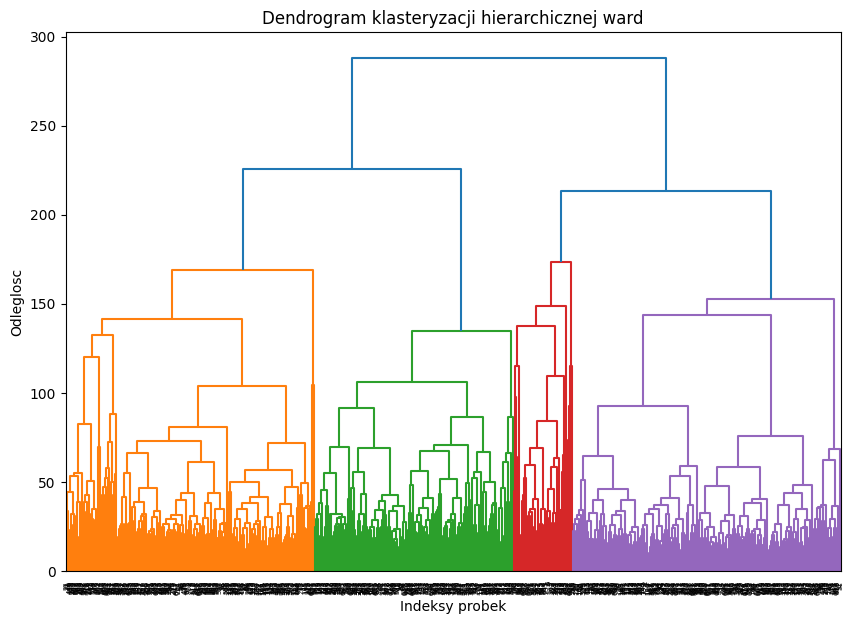

In [19]:
import numpy as np
import scipy.cluster.hierarchy as sch
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
import matplotlib.pyplot as plt

scaler = StandardScaler()
data_scaled = scaler.fit_transform(df)

metoda='ward'
# metoda='single'
# metoda='complete'
linked = linkage(data_scaled, method=metoda)  

kmeans = KMeans(n_clusters=3, random_state=42)
labels_kmeans = kmeans.fit_predict(data_scaled)

pca = PCA(n_components=2)
data_pca = pca.fit_transform(data_scaled)

# Wyodrebnienie klastrow na wybranym poziomie
clusters = fcluster(linked, t=3, criterion='maxclust')

score_hier = silhouette_score(data_scaled, clusters)
score_kmeans = silhouette_score(data_scaled, labels_kmeans)

ari = adjusted_rand_score(clusters, labels_kmeans)

print("Silhouette hierarchiczna:", score_hier)
print("Silhouette KMeans:", score_kmeans)
print("ARI:", ari)

# Wizualizacja dendrogramu
plt.figure(figsize=(10, 7))
dendrogram(linked, orientation='top', distance_sort='descending', show_leaf_counts=True)
plt.title(f'Dendrogram klasteryzacji hierarchicznej {metoda}')
plt.xlabel('Indeksy probek')
plt.ylabel('Odleglosc')
plt.show()

Silhouette hierarchiczna: 0.6755223778278555
Silhouette KMeans: 0.08561320262378386
ARI: -0.00039389433596732345


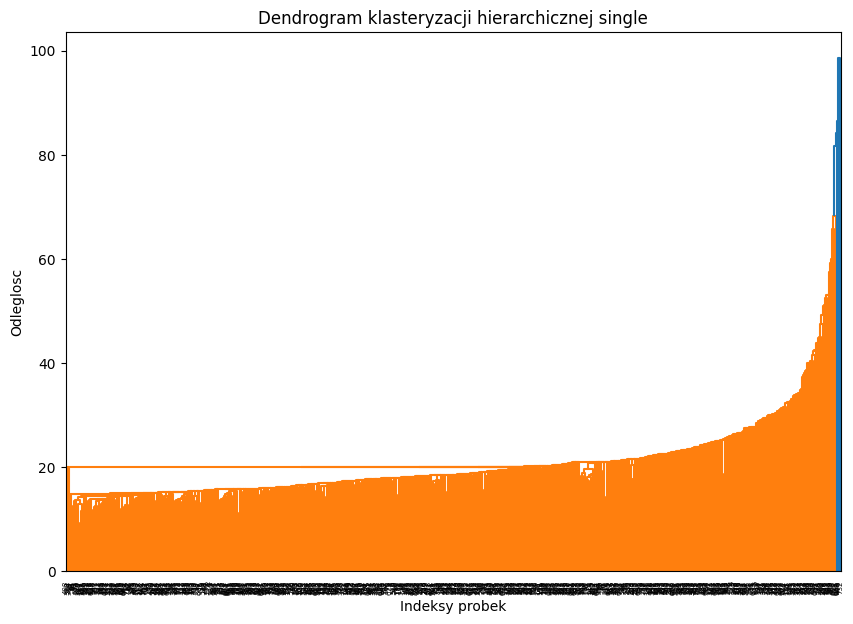

In [18]:
import numpy as np
import scipy.cluster.hierarchy as sch
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
import matplotlib.pyplot as plt

scaler = StandardScaler()
data_scaled = scaler.fit_transform(df)

# metoda='ward'
metoda='single'
# metoda='complete'
linked = linkage(data_scaled, method=metoda)  

kmeans = KMeans(n_clusters=3, random_state=42)
labels_kmeans = kmeans.fit_predict(data_scaled)

pca = PCA(n_components=2)
data_pca = pca.fit_transform(data_scaled)

# Wyodrebnienie klastrow na wybranym poziomie
clusters = fcluster(linked, t=3, criterion='maxclust')

score_hier = silhouette_score(data_scaled, clusters)
score_kmeans = silhouette_score(data_scaled, labels_kmeans)

ari = adjusted_rand_score(clusters, labels_kmeans)

print("Silhouette hierarchiczna:", score_hier)
print("Silhouette KMeans:", score_kmeans)
print("ARI:", ari)

# Wizualizacja dendrogramu
plt.figure(figsize=(10, 7))
dendrogram(linked, orientation='top', distance_sort='descending', show_leaf_counts=True)
plt.title(f'Dendrogram klasteryzacji hierarchicznej {metoda}')
plt.xlabel('Indeksy probek')
plt.ylabel('Odleglosc')
plt.show()

Silhouette hierarchiczna: 0.6719891081324816
Silhouette KMeans: 0.08561320262378386
ARI: -0.00025827999711554626


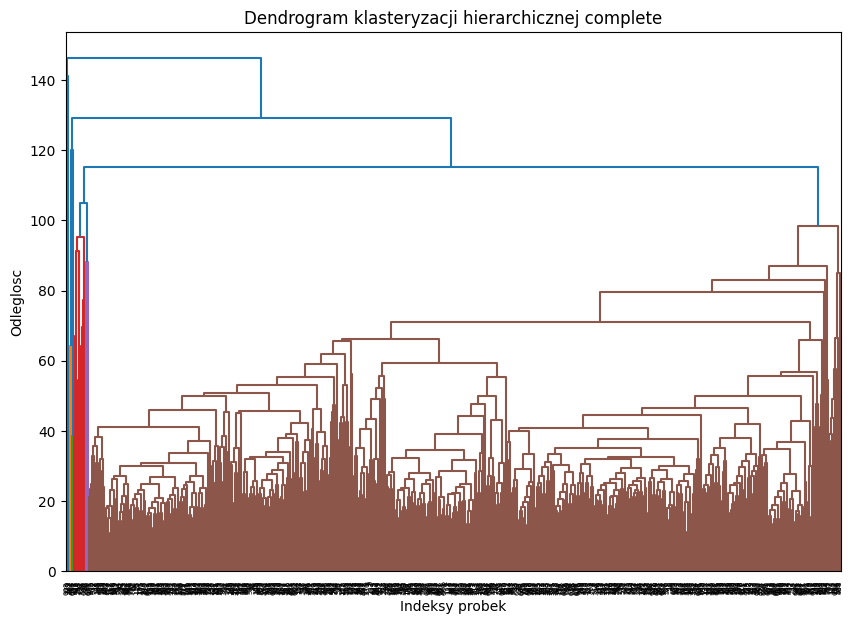

In [20]:
import numpy as np
import scipy.cluster.hierarchy as sch
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
import matplotlib.pyplot as plt

scaler = StandardScaler()
data_scaled = scaler.fit_transform(df)

# metoda='ward'
# metoda='single'
metoda='complete'
linked = linkage(data_scaled, method=metoda)  

kmeans = KMeans(n_clusters=3, random_state=42)
labels_kmeans = kmeans.fit_predict(data_scaled)

pca = PCA(n_components=2)
data_pca = pca.fit_transform(data_scaled)

# Wyodrebnienie klastrow na wybranym poziomie
clusters = fcluster(linked, t=3, criterion='maxclust')

score_hier = silhouette_score(data_scaled, clusters)
score_kmeans = silhouette_score(data_scaled, labels_kmeans)

ari = adjusted_rand_score(clusters, labels_kmeans)

print("Silhouette hierarchiczna:", score_hier)
print("Silhouette KMeans:", score_kmeans)
print("ARI:", ari)

# Wizualizacja dendrogramu
plt.figure(figsize=(10, 7))
dendrogram(linked, orientation='top', distance_sort='descending', show_leaf_counts=True)
plt.title(f'Dendrogram klasteryzacji hierarchicznej {metoda}')
plt.xlabel('Indeksy probek')
plt.ylabel('Odleglosc')
plt.show()

7.2 Metody niehierarchiczne

k: 1 : inertia : 570779.9999999998
k: 2 : inertia : 522877.15051446384
k: 3 : inertia : 492507.44543146365
k: 4 : inertia : 479155.4956253755
k: 5 : inertia : 463854.04089749226
k: 6 : inertia : 450898.4117880074
k: 7 : inertia : 441774.7647452686
k: 8 : inertia : 425235.59341939946
k: 9 : inertia : 413057.39124767133
k: 10 : inertia : 402170.29945680045


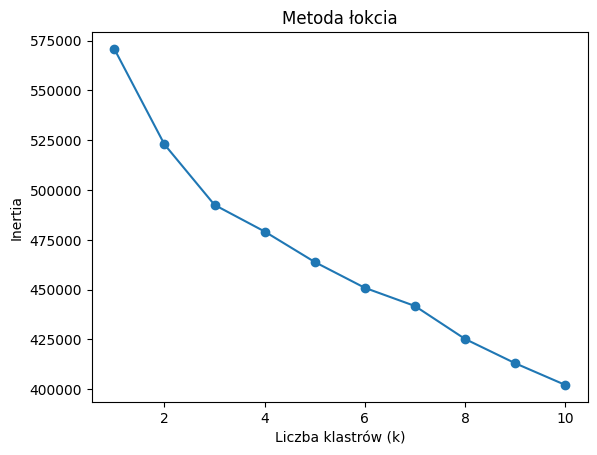

In [8]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

#metoda łokcia
#   wybierasz takie k, przy którym spadek inertia zaczyna wyraźnie zwalniać.

inertia = []
k_values = range(1, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(data_scaled)
    inertia.append(kmeans.inertia_)
    print(f"k: {k} : inertia : {kmeans.inertia_}")

plt.plot(k_values, inertia, marker='o')
plt.xlabel("Liczba klastrów (k)")
plt.ylabel("Inertia")
plt.title("Metoda łokcia")
plt.show()

52220.27201443632


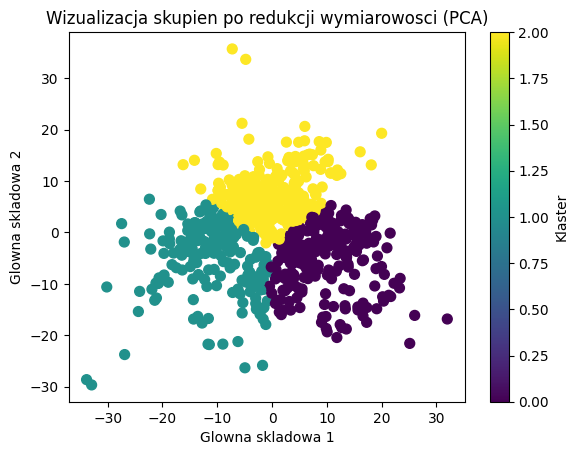

In [4]:
scaler = StandardScaler()
data_scaled = scaler.fit_transform(df)

# Redukcja wymiarowosci za pomoca PCA do 2d
pca = PCA(n_components=2)
data_pca = pca.fit_transform(data_scaled)

# Klasteryzacja k-means (na potrzeby wizualizacji)
k=3
kmeans = KMeans(n_clusters=k, random_state=42)
labels = kmeans.fit_predict(data_pca)

#metoda łokcia suma odległości punktów od ich centroidów (środków klastrów) mała wartość = lepiej  im więcej klastrów, tym zawsze będzie mniejsza
print(kmeans.inertia_)

# Wizualizacja wynikow
plt.scatter(data_pca[:, 0], data_pca[:, 1], c=labels, cmap='viridis', s=50)
plt.xlabel('Glowna skladowa 1')
plt.ylabel('Glowna skladowa 2')
plt.title('Wizualizacja skupien po redukcji wymiarowosci (PCA)')
plt.colorbar(label='Klaster')
plt.show()

34184.157356489886


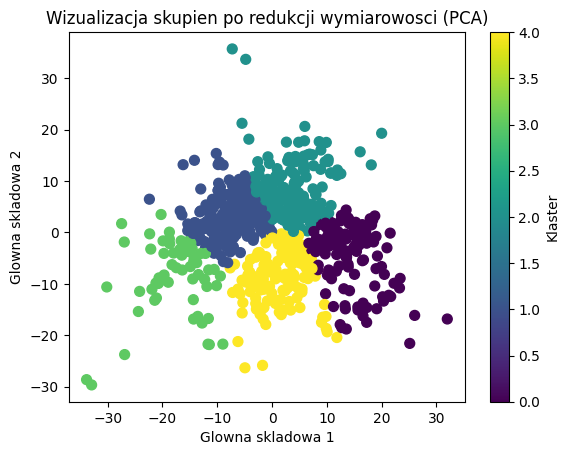

In [4]:
scaler = StandardScaler()
data_scaled = scaler.fit_transform(df)

# Redukcja wymiarowosci za pomoca PCA do 2d
pca = PCA(n_components=2)
data_pca = pca.fit_transform(data_scaled)

# Klasteryzacja k-means (na potrzeby wizualizacji)
k=5
kmeans = KMeans(n_clusters=k, random_state=42)
labels = kmeans.fit_predict(data_pca)

#metoda łokcia suma odległości punktów od ich centroidów (środków klastrów) mała wartość = lepiej  im więcej klastrów, tym zawsze będzie mniejsza
print(kmeans.inertia_)

# Wizualizacja wynikow
plt.scatter(data_pca[:, 0], data_pca[:, 1], c=labels, cmap='viridis', s=50)
plt.xlabel('Glowna skladowa 1')
plt.ylabel('Glowna skladowa 2')
plt.title('Wizualizacja skupien po redukcji wymiarowosci (PCA)')
plt.colorbar(label='Klaster')
plt.show()

7.1 Metoda PCA

In [7]:
from sklearn.metrics import silhouette_score, adjusted_rand_score
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# dane
path = r"C:\Users\USER098\Documents\GitHub\Artifical_Inteligence_lesson\Data\pd_speech_features.csv"
df = pd.read_csv(path, encoding="utf-8")

# skalowanie
scaler = StandardScaler()
data_scaled = scaler.fit_transform(df)

# 🔹 KMeans PRZED PCA
kmeans_original = KMeans(n_clusters=3, random_state=42)
labels_original = kmeans_original.fit_predict(data_scaled)

# 🔹 PCA
pca = PCA(n_components=2)
data_pca = pca.fit_transform(data_scaled)

# 🔹 KMeans PO PCA
kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(data_pca)

score_original = silhouette_score(data_scaled, labels_original)
print(f"Silhouette (przed PCA): {score_original}")

score_pca = silhouette_score(data_pca, labels)
print(f"Silhouette (po PCA): {score_pca}")

# 🔹 porównanie klastrów
ari = adjusted_rand_score(labels_original, labels)
print(f"Podobieństwo klastrów (ARI): {ari}")

print(f"inertia {kmeans.inertia_}")

Silhouette (przed PCA): 0.08561320262378386
Silhouette (po PCA): 0.37586765990009513
Podobieństwo klastrów (ARI): 0.8893156116014236
inertia 52220.273359916944
